# Открытие файла с данными и изучение общей информации.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

       total_images  last_price  total_area first_day_exposition  rooms  \
0                20  13000000.0      108.00  2019-03-07T00:00:00      3   
1                 7   3350000.0       40.40  2018-12-04T00:00:00      1   
2                10   5196000.0       56.00  2015-08-20T00:00:00      2   
3                 0  64900000.0      159.00  2015-07-24T00:00:00      3   
4                 2  10000000.0      100.00  2018-06-19T00:00:00      2   
...             ...         ...         ...                  ...    ...   
23694             9   9700000.0      133.81  2017-03-21T00:00:00      3   
23695            14   3100000.0       59.00  2018-01-15T00:00:00      3   
23696            18   2500000.0       56.70  2018-02-11T00:00:00      2   
23697            13  11475000.0       76.75  2017-03-28T00:00:00      2   
23698             4   1350000.0       32.30  2017-07-21T00:00:00      1   

       ceiling_height  floors_total  living_area  floor is_apartment  ...  \
0                2.70 

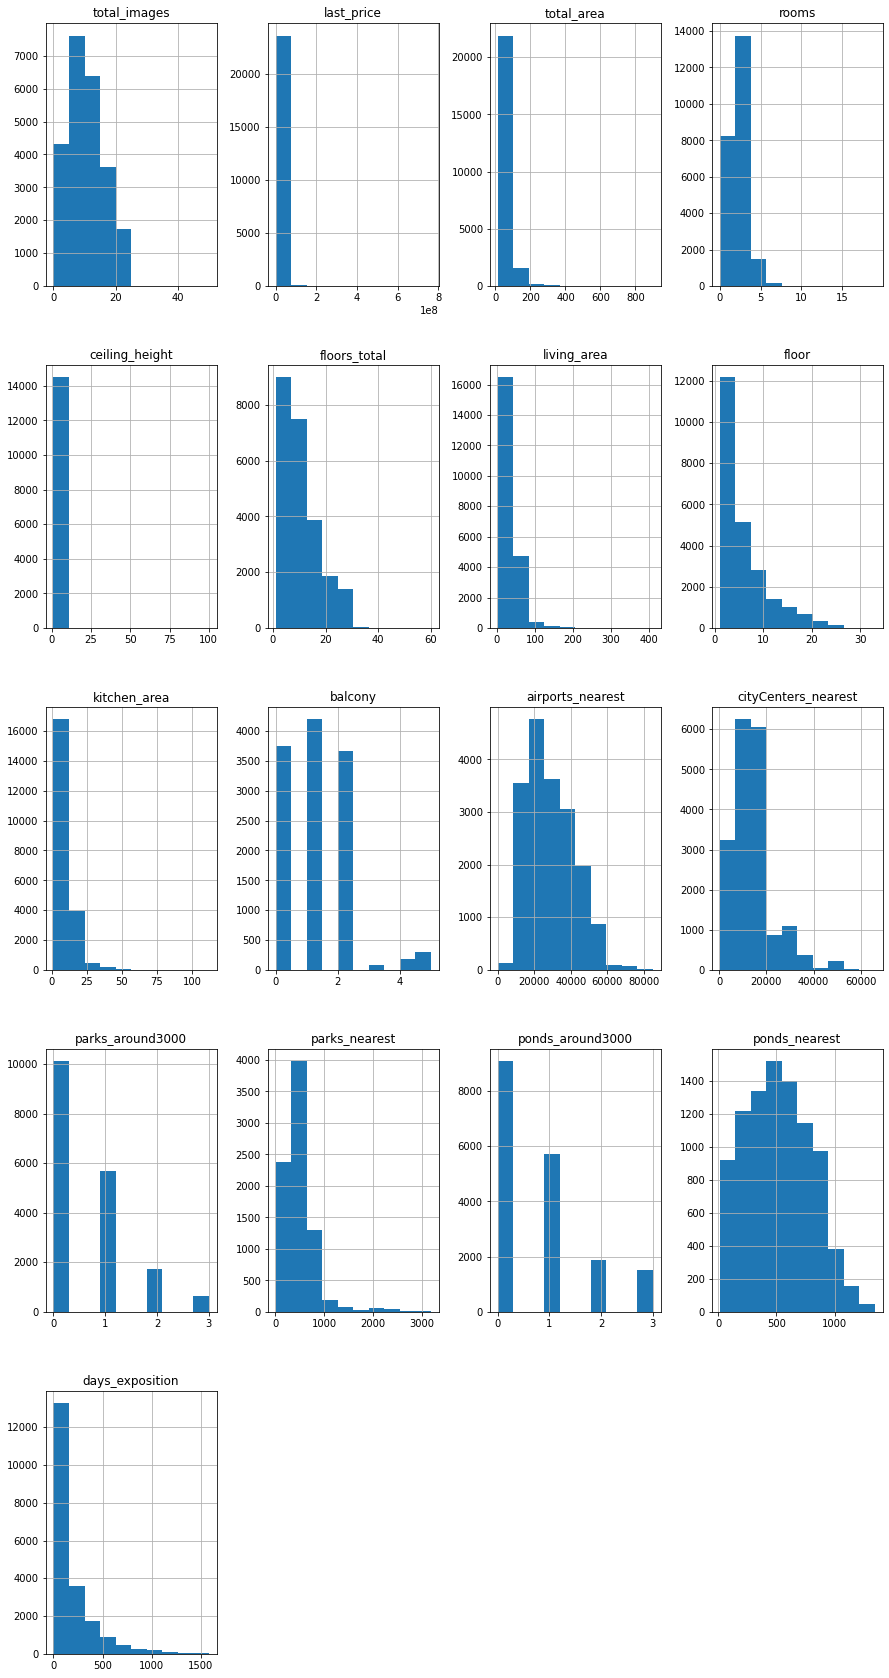

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    data= pd.read_csv('../data/real_estate_data.csv', sep='\t')
except:
    data= pd.read_csv('../data/real_estate_data.csv', sep='\t')
data.info()
data.hist(bins=10, figsize=(15,30));
display(data)

ceiling_height- нулевые значения
floors_total- нулевые значения, также должен быть тип int64, т.к значение этажей целое
living_area- нулевые значения
is_apartment- нулевые значение, тип данных должен быть булевым
kitchen_area-нулевые значения
balcony- нулевые значения, так же тип данных должен быть int64
locality_name- нулевые значения 
airports_nearest- нулевые значения 
cityCenters_nearest- нулевые значения 
parks_around3000- нулевые значения, также должен быть тип int64, т.к значение этажей целое
ponds_around3000- нулевые значения, также должен быть тип int64, т.к значение этажей целое
ponds_nearest- нулевые значения 
parks_nearest- нулевые значения 
days_exposition- нулевые значения также должен быть тип int64, т.к значение этажей целое
first_day_exposition- нулевые значения, тип данных должен быть заменен на to_datetime

# Предобработка данных


In [ ]:
data.columns
data.head(30)#проверяем названия столбцов для дальнейшей удобной работыб все названия соответствуют параметрамб изменения не требуются

    total_images  last_price  total_area first_day_exposition  rooms  \
0             20  13000000.0      108.00  2019-03-07T00:00:00      3   
1              7   3350000.0       40.40  2018-12-04T00:00:00      1   
2             10   5196000.0       56.00  2015-08-20T00:00:00      2   
3              0  64900000.0      159.00  2015-07-24T00:00:00      3   
4              2  10000000.0      100.00  2018-06-19T00:00:00      2   
5             10   2890000.0       30.40  2018-09-10T00:00:00      1   
6              6   3700000.0       37.30  2017-11-02T00:00:00      1   
7              5   7915000.0       71.60  2019-04-18T00:00:00      2   
8             20   2900000.0       33.16  2018-05-23T00:00:00      1   
9             18   5400000.0       61.00  2017-02-26T00:00:00      3   
10             5   5050000.0       39.60  2017-11-16T00:00:00      1   
11             9   3300000.0       44.00  2018-08-27T00:00:00      2   
12            10   3890000.0       54.00  2016-06-30T00:00:00   

In [ ]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format = '%Y-%m-%dT%H:%M:%S')
# заменим пропуски в balcony на 0 и изменим тип данных на int
data['balcony'] = data['balcony'].fillna(0).astype('int64')
# Приводим тип к целому числу количество парков и заменяем пропущенные значения на 0
data['parks_around3000'] = data['parks_around3000'].fillna(value=0).astype('int64')
# Приводим тип к целому числу количество парков и заменяем пропущенные значения на 0
data['ponds_around3000'] = data['ponds_around3000'].fillna(value=0).astype('int64')
# Выясняем количество значений в аппартаментах, всего аппартаментов - 50, заменяем пропущенные значения на Falseб приводим к булевому типу
data['is_apartment'] = data['is_apartment'].fillna(value=False).astype('bool')
# Удаляем записи, где отсутствует локация, т.к причина отсутствия заполнения нам неизвестна
#data.dropna(subset=['locality_name'], inplace=True)
#заменим пропуски в высоте потолка на медианное значениеб в столбце есть выбросы и аномальные значенияб максимальная высота потолка 100б скорее всего
#опечатка скорее всего связана с человеческим фактором, можно ее не трогатьб т.к медианное значение равно 2.65, этим значением мы заполним пропуски
data['ceiling_height'].fillna(data['ceiling_height'].median(), inplace=True)
#data['ceiling_height'].describe()
#такую же операцию провоим с кухней и жилой площадью, в максимальном значении плозаи 
#и кухни так е пресутствуют аномально высокие значенияб не буем заострять на них внимание, возможно это усадьба
data['living_area'].fillna(data['living_area'].median(), inplace=True)
#data['living_area'].describe()
data['kitchen_area'].fillna(data['kitchen_area'].median(), inplace=True)
#data['kitchen_area'].describe()
#данные столбцы оставим без измененийб т.к среднее значение или меианное не подойут ля заполненияб 0 также не удастся поставить
data['airports_nearest'].value_counts()
data['cityCenters_nearest'].value_counts()
data['parks_nearest'].value_counts()
data['ponds_nearest'].value_counts()
data['days_exposition'].value_counts()
data.isnull().sum()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        23699 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           23699 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  bool          
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          23699 non-null  float64       
 13  balcony         

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        23699 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           23699 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  bool          
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          23699 non-null  float64       
 13  balcony         

In [ ]:
data['locality_name'].unique()
#сначала переведем в строчные буквы
data['locality_name'] = data['locality_name'].str.lower()
#затем заменим ё на е и оставим только название населенного пункта
data['locality_name'] = (
    data['locality_name']
    .str.replace('ё', 'е')
    .replace(['поселок ','при железнодорожной станции ', 'платформа ', 
             'садоводческое некоммерческое товарищество ',
             'садовое товарищество ', 'станции ', 'село ', 'пансионат ', 'городского типа ',
             'деревня ', 'городской поселок '], '', regex=True))
#выведем уникальные значения
data['locality_name'].unique()

array(['санкт-петербург', 'шушары', 'городской янино-1', 'парголово',
       'мурино', 'ломоносов', 'сертолово', 'петергоф', 'пушкин',
       'кудрово', 'коммунар', 'колпино', 'красный бор', 'гатчина',
       'федоровское', 'выборг', 'кронштадт', 'кировск', 'новое девяткино',
       'металлострой', 'лебяжье', 'сиверский', 'молодцово',
       'кузьмоловский', 'новая ропша', 'павловск', 'пикколово',
       'всеволожск', 'волхов', 'кингисепп', 'приозерск', 'сестрорецк',
       'куттузи', 'аннино', 'ефимовский', 'плодовое', 'заклинье',
       'торковичи', 'первомайское', 'красное село', 'понтонный',
       'сясьстрой', 'старая', 'лесколово', 'новый свет', 'сланцы',
       'путилово', 'ивангород', 'шлиссельбург', 'никольское',
       'зеленогорск', 'сосновый бор', 'оржицы', 'кальтино', 'романовка',
       'бугры', 'рощино', 'кириши', 'луга', 'волосово', 'отрадное',
       'павлово', 'оредеж', 'копорье', 'молодежное', 'тихвин', 'победа',
       'нурма', 'синявино', 'тосно', 'стрельна', 'бокс

# Считаем и обавляем таблицу


In [ ]:
#посчитаем цену квадратного метра
data['price_per_square_meter'] = data['last_price'] / data['total_area']
#data['price_per_square_meter'].info()
#меняем тип на целочисленный
data['price_per_square_meter'] = data['price_per_square_meter'].astype('int64')

# добавляем столбцы дня недели, месяца и года
data['weekday'] = data['first_day_exposition'].dt.weekday
data['month'] = data['first_day_exposition'].dt.month
data['year'] = data['first_day_exposition'].dt.year
# создаим функцию для заполнения нового столбца с типом этажа
def floor_level(row):
    if row['floor'] == 1:
        return 'первый'
    elif row['floor'] == row['floors_total']:
        return 'последний'
    else:
        return 'другой'
data['floor_level'] = data.apply(floor_level,axis=1)
#создатим столбец расстояния до центра перевеем в км и округлим его
data['center_distance']=data['cityCenters_nearest']/1000
data['center_distance']=data['center_distance'].round()
data.head()

   total_images  last_price  total_area first_day_exposition  rooms  \
0            20  13000000.0       108.0           2019-03-07      3   
1             7   3350000.0        40.4           2018-12-04      1   
2            10   5196000.0        56.0           2015-08-20      2   
3             0  64900000.0       159.0           2015-07-24      3   
4             2  10000000.0       100.0           2018-06-19      2   

   ceiling_height  floors_total  living_area  floor  is_apartment  ...  \
0            2.70          16.0         51.0      8         False  ...   
1            2.65          11.0         18.6      1         False  ...   
2            2.65           5.0         34.3      4         False  ...   
3            2.65          14.0         30.0      9         False  ...   
4            3.03          14.0         32.0     13         False  ...   

   parks_nearest  ponds_around3000  ponds_nearest  days_exposition  \
0          482.0                 2          755.0         

# Проводим исследовательский анализ данных


In [ ]:
data = data.query('last_price < 20e6 and ceiling_height > 2 and ceiling_height < 4 and total_area < 300 and rooms < 7')

count    22844.000000
mean        56.436255
std         23.955964
min         12.000000
25%         40.000000
50%         51.000000
75%         67.000000
max        263.800000
Name: total_area, dtype: float64

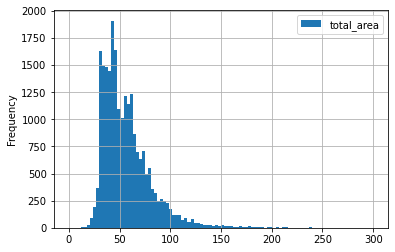

In [ ]:
#изучим общую площадь, распределение данных нормальное, есть выбросы, но они не повлияют на качество анализ
data.plot(y='total_area', xlabel='Квадратные метры', ylabel='Количество квартир', kind='hist', bins=100, grid=True, range=(0, 300))
data['total_area'].describe()

count    22844.000000
mean         2.682400
std          0.184634
min          2.200000
25%          2.600000
50%          2.650000
75%          2.700000
max          3.980000
Name: ceiling_height, dtype: float64

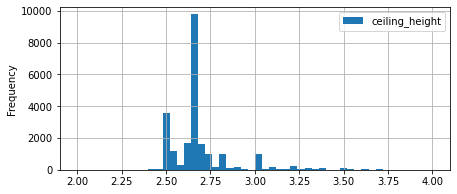

In [ ]:
#при изучении высоты потолков, вытянем только те данные в которых потолки выше 2м и ниже 4м
data.plot(y='ceiling_height', xlabel='Высота', ylabel='Количество квартир', kind='hist', bins=50, grid=True, figsize=(7,3), range=(2, 4))
data['ceiling_height'].describe()

count    22844.000000
mean         2.001007
std          0.963525
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: rooms, dtype: float64

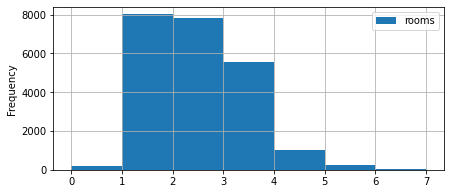

In [ ]:
#изучаем количество комнат
data.plot(y='rooms', xlabel='Кол-во комнат', ylabel='Количество квартир', kind='hist', bins=7, grid=True, figsize=(7,3), range=(0, 7))
data['rooms'].describe()

count    2.284400e+04
mean     5.390207e+06
std      3.164869e+06
min      1.219000e+04
25%      3.400000e+06
50%      4.550000e+06
75%      6.495500e+06
max      1.999900e+07
Name: last_price, dtype: float64

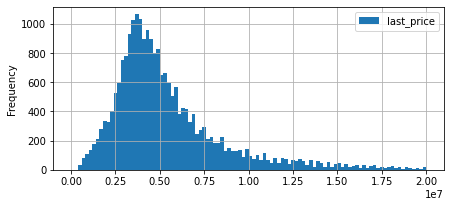

In [ ]:
#изучаем общую стоимость
data.plot(y='last_price', xlabel='Стоимость', ylabel='Количество квартир', kind='hist', bins=100, grid=True, figsize=(7,3), range=(0, 20000000))
data['last_price'].describe()

count    22844.000000
mean        32.166116
std         15.531540
min          2.000000
25%         19.000000
50%         30.000000
75%         40.000000
max        171.000000
Name: living_area, dtype: float64

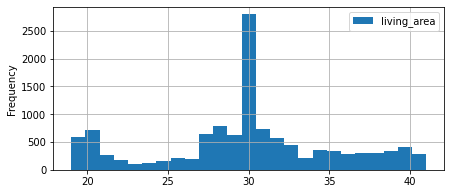

In [ ]:
#изучаем жилую площадь
data.plot(y='living_area', xlabel='Квадратные метры', ylabel='Количество квартир', kind='hist', bins=25, grid=True, figsize=(7,3), range=(19, 41))
data['living_area'].describe()

count    22844.000000
mean        10.005916
std          4.493953
min          1.300000
25%          7.200000
50%          9.100000
75%         11.000000
max        100.700000
Name: kitchen_area, dtype: float64

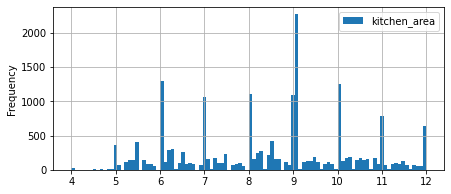

In [ ]:
#изучаем площадь кухни
data.plot(y='kitchen_area', xlabel='Квадратные метры', ylabel='Количество квартир', kind='hist', bins=100, grid=True, figsize=(7,3), range=(4, 12))
data['kitchen_area'].describe()

count    22844.000000
mean         5.904920
std          4.907557
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         33.000000
Name: floor, dtype: float64

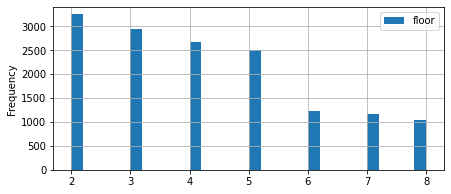

In [ ]:
#изучаем количество этажей
data.plot(y='floor', xlabel='Кол-во этажей', ylabel='Количество квартир', kind='hist', bins=30, grid=True, figsize=(7,3), range=(2, 8))
data['floor'].describe()

count    17368.000000
mean        14.532589
std          8.567769
min          0.000000
25%         10.000000
50%         13.000000
75%         16.000000
max         66.000000
Name: center_distance, dtype: float64

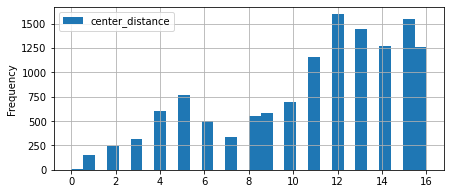

In [ ]:
#изучаем расстояние до центра города в км
data.plot(y='center_distance', xlabel='Расстояние в км', ylabel='Количество квартир', kind='hist', bins=30, grid=True, figsize=(7,3), range=(0, 16))
data['center_distance'].describe()

count    7489.000000
mean      494.084524
std       342.962693
min         1.000000
25%       289.000000
50%       456.000000
75%       615.000000
max      3190.000000
Name: parks_nearest, dtype: float64

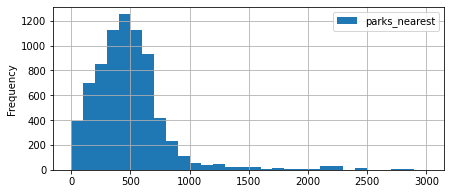

In [ ]:
#изучаем расстояние до парка в м
data.plot(y='parks_nearest', xlabel='Расстояние в м', ylabel='Количество квартир', kind='hist', bins=30, grid=True, figsize=(7,3), range=(0, 3000))
data['parks_nearest'].describe()

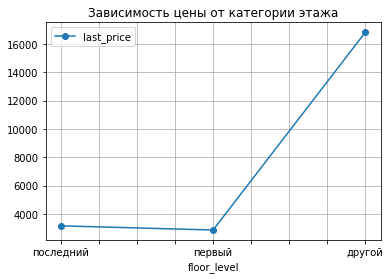

In [ ]:
# изучим зависимость цены по категории этажа
(
    data.pivot_table(index='floor_level', values='last_price', aggfunc='count').sort_values(by='floor_level', ascending=False)
    .plot( grid=True, style='o-', title='Зависимость цены от категории этажа')
);

# Вывод:
1.Большинство квартир составляют меньше 100 квадратный метров, средний размер квартиры составляет 60.3 кв.м, медианное значение 52 кв.м, наибольшая плотность квартир расположены от 30 до 60 кв.м. 
2.Жилая площадь имеет показатели средней- 34.1 кв.м, а медиана-30 кв.м, два пика графика вызваны, вероятно, тем, что это жилые площади для 1-комнатной, затем для 2-комнатной и после этого для 3-комнатной квартиры. Самая высокая плотность в диапазоне от 10 до 40 кв.м. 
3.Показатели кухонь почти одинаковые ~10 кв.м в большинстве квартир.
4.Среднее значение стоимости квартир- 5.4 млн. рублей, медианный показатель- 6.5 млн. рублейб распределение данных Гаусса.
5.Большинство жителей живут в 2х комнатной квартиреб есть показатели в виде 19 комнат, но скорее всего это частый большой дом.
6.Большинсво квартир имеют потолки 2.7м.(медианое значение, не сильно отличается от среднего, можно округлить, разница в пару см. не критична)б имеются аномальные показатели в виде 100м., эти данные лучше уточнить у того, кто заполнял таблицу, даже если "0" был назат сучайно, в 10 метровые потолки слабо верится.
7.Большиство квартир имеют этажность от 4-5 этажей, максимальный показатель в 33 этажа, критических показателей не наблюдается.
8.Среднее растояние до центра от квартиры 14 км., медианный показатель 13 км.
9.В частности парки находятся от квартир на расстоянии 450-500м.

Во всех данных есть критические значения: 0 комнат, высоты потолков в 100 метров. Эти данные лучше уточнить у сотрудников заполнявших таблицу.

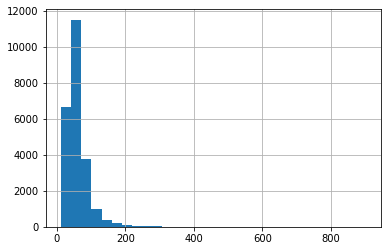

In [ ]:
data2 = pd.read_csv('../data/real_estate_data.csv', sep='\t')
(data2['total_area']).hist(bins=30);

# Изучаем, как быстро продавались квартиры

count    19902.000000
mean       177.735102
std        216.454476
min          1.000000
25%         44.000000
50%         93.000000
75%        226.000000
max       1580.000000
Name: days_exposition, dtype: float64

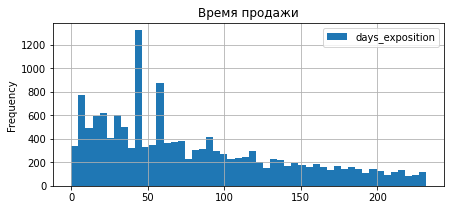

In [ ]:
data.plot(y='days_exposition', title='Время продажи', ylabel='Количество квартир', xlabel='Дни', kind='hist', bins=50, range=(0,232), grid= True, figsize=(7,3))
data[data['days_exposition']!=0]['days_exposition'].value_counts()
data[data['days_exposition']!=0]['days_exposition'].describe()

Вывод:
Среднее время продажи равен 181 дню, а медианный показатель продажи - 95 дней.
Большинством квартиы продаются за срок в 100 дне, имеетсяь большое число квартир, проданных всего за несколько дней после публикаци,. также естьквартирыы, которые продавались нескольколетв Судя по показателям квантилей быстрой продажей можно назвать продажи меньше 45 дней, а долгой свыше 231 дня. Необходимо будет отфильтровать значения в новый датафрейм, как как очень много аномальных показателей квартир проданных за 45,60, 7, 30, 90 дней. Исходя из диаграмы размаха, нормальные значения лежат в рпеделах от 1 до 500..

count    19902.000000
mean       177.735102
std        216.454476
min          1.000000
25%         44.000000
50%         93.000000
75%        226.000000
max       1580.000000
Name: days_exposition, dtype: float64

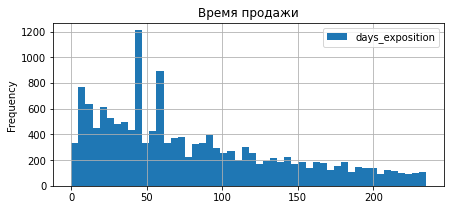

In [ ]:
data.plot(y='days_exposition', title='Время продажи', ylabel='Количество квартир', xlabel='Дни', kind='hist', bins=50, range=(0,235), grid= True, figsize=(7,3))
data['days_exposition'].value_counts()
data['days_exposition'].describe()


Вывод:
Среднее значение продажи составляет 180 дня, медианное значение составляет 95 дня, медианное значение для нас более показательное, так как не зависит от критических значений.

# Определяем факторы, которые больше всего влияют на общую (полную) стоимость объекта.

In [ ]:
data.head()

   total_images  last_price  total_area first_day_exposition  rooms  \
0            20  13000000.0       108.0           2019-03-07      3   
1             7   3350000.0        40.4           2018-12-04      1   
2            10   5196000.0        56.0           2015-08-20      2   
4             2  10000000.0       100.0           2018-06-19      2   
5            10   2890000.0        30.4           2018-09-10      1   

   ceiling_height  floors_total  living_area  floor  is_apartment  ...  \
0            2.70          16.0         51.0      8         False  ...   
1            2.65          11.0         18.6      1         False  ...   
2            2.65           5.0         34.3      4         False  ...   
4            3.03          14.0         32.0     13         False  ...   
5            2.65          12.0         14.4      5         False  ...   

   parks_nearest  ponds_around3000  ponds_nearest  days_exposition  \
0          482.0                 2          755.0         

0.05527340981630568

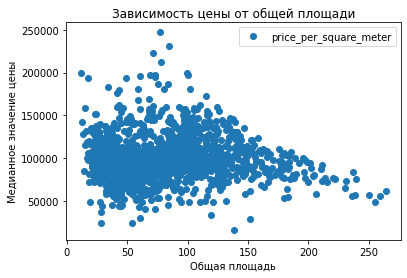

In [ ]:
#изучаем зависимость цены от общей площади, создаем сводную таблицу, строим график и выводим корреляцию.
pivot_total_area = data.pivot_table(index='total_area', values = 'price_per_square_meter', aggfunc = ['count','mean','median'])
pivot_total_area.plot(title='Зависимость цены от общей площади', ylabel='Медианное значение цены', xlabel='Общая площадь', y = 'median',  style = 'o')
data['total_area'].corr(data['price_per_square_meter'])

Вывод: 
1) Зависимость между ценой и общей площадью имеет низкий показатель, это говорит о том, что при увеличении. Самая популярная стоимость 1 кв.м. в диапазоне от 0-200000 тысяч рублей.


-0.033507433868387684

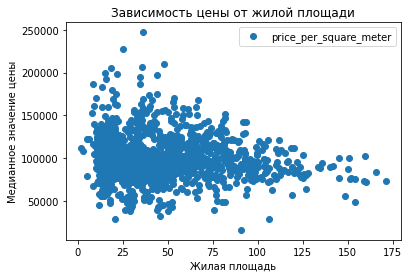

In [ ]:
#изучаем зависимость цены от жилой площади, создаем сводную таблицу, строим график и выводим корреляцию.
pivot_living_area= data.pivot_table(index='living_area', values='price_per_square_meter', aggfunc = ['count','mean','median'])
pivot_living_area.plot(title= 'Зависимость цены от жилой площади', y='median', xlabel='Жилая площадь', ylabel='Медианное значение цены', style='o')
data['living_area'].corr(data['price_per_square_meter'])

Вывод:
1) Графики показателей зависимости общей и жилой площади оцень походи и имеют схожую корреляцию, зависимости низкие, чем больше площадь, 
тем ненамного больше и его стоимость. 
2) При этом интересно то, что показатели зависимости жилой площади ниже, чем у общей площади, это говорит о том, что просторные ванные,
коридоры и кухни влияют на стоимость квадратного метра сильнее, чем размер комнат.

0.2659394192767735

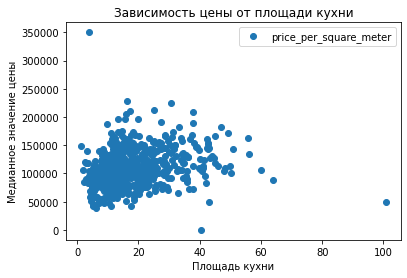

In [ ]:
#изучаем зависимость цены от площади кухни, создаем сводную таблицу, строим график и выводим корреляцию.
pivot_living_area= data.pivot_table(index='kitchen_area', values='price_per_square_meter', aggfunc = ['count','mean','median'])
pivot_living_area.plot(title= 'Зависимость цены от площади кухни', y='median', xlabel='Площадь кухни', ylabel='Медианное значение цены', style='o')
data['kitchen_area'].corr(data['price_per_square_meter'])

Вывод:
1) Что и требовалось доказать, зависимость цены от площади кухни выше, чем у зависимости цены от жилой площади, поэтому корреляция выше.

-0.13194420318984576

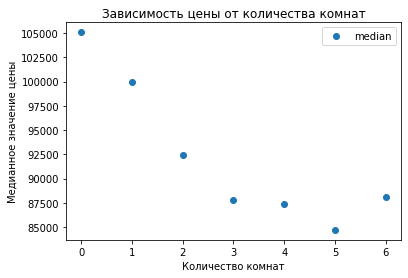

In [ ]:
#изучаем зависимость цены от количества комнат, создаем сводную таблицу, строим график и выводим корреляцию.
pivot_rooms= data.pivot_table(index='rooms', values='price_per_square_meter', aggfunc = ['count','mean','median'])
pivot_rooms.columns = ['count','mean','median']
pivot_rooms.plot(title= 'Зависимость цены от количества комнат', xlabel='Количество комнат', ylabel='Медианное значение цены', y='median', style='o')
data['rooms'].corr(data['price_per_square_meter'])

Вывод:
1) Стоимость квадратного метра падаем при приближении к квартирам, имеющим 3 комнаты, затем стоимость снова растет до 8 и опять падает, при это слишком низкая зависимость цены от количества комнат.

             count          mean  median
floor_level                             
другой       16829  98849.805871   97372
первый        2860  79957.926224   80872
последний     3155  86273.201902   86151

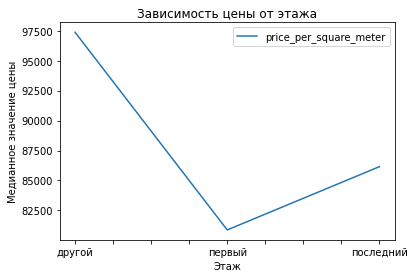

In [ ]:
#изучаем зависимость цены от этажа, создаем сводную таблицу, строим график, корреляцию вывести не удастся из-за типа разного типа данных.
pivot_floor_level=data.pivot_table(index='floor_level', values='price_per_square_meter', aggfunc = ['count','mean','median'])
pivot_floor_level.plot(title= 'Зависимость цены от этажа', xlabel='Этаж', ylabel='Медианное значение цены', y='median')
pivot_floor_level.columns= ['count','mean','median']
pivot_floor_level

Вывод:
1) По графику можно сказать, что самые дешевые квартиры на 1 этаже, но и на последнем этаже не самые дорогие квартиры.

         count          mean  median
weekday                             
1         4046  95327.943895   94875
2         3830  95344.031070   94548
3         4110  94673.834063   93891
0         3476  94626.969793   93750
4         3871  94821.466804   93750
6         1638  93819.874237   93717
5         1873  93319.192205   92519

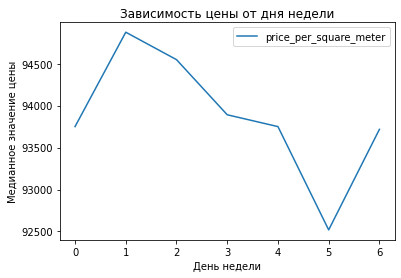

In [ ]:
pivot_weekday = data.pivot_table(index='weekday', values='price_per_square_meter', aggfunc = ['count','mean','median'])
pivot_weekday.plot(title= 'Зависимость цены от дня недели', xlabel='День недели', ylabel='Медианное значение цены', y='median')
pivot_weekday.columns= ['count','mean','median']
pivot_weekday.sort_values(by='median', ascending = False)

Вывод:
1) Самый высокий показатель стоимости приходится на вторник, хотя неделя начинается с понедельника, скорее всего такая тенденция связанна с тем, что люди находятся в повышенной занятости первые рабочие дни недели и интерес к покупке жилья не является для них в приоритете.
2) Самая низкая цена приходится на субботу, связанно скорее всего с тем, что у большинства людей выходной и продавцы борятся между собой с помощью занижения цен.

       count          mean   median
month                              
4       2308  96550.720104  95525.5
8       1688  95683.826422  95140.0
9       1917  96069.962441  94720.0
11      2277  95142.385156  94420.0
3       2498  95039.843074  94357.0
1       1439  94961.558721  94300.0
2       2541  94179.165289  94130.0
7       1622  94418.918002  93883.0
10      2060  94312.127670  93544.5
12      1569  93581.353728  93065.0
5       1230  94144.828455  92000.0
6       1695  91935.158112  91708.0

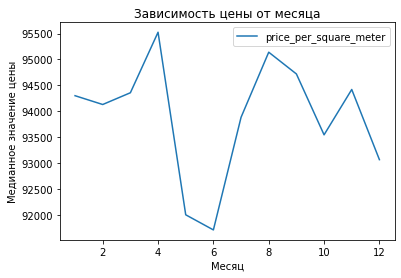

In [ ]:
pivot_month = data.pivot_table(index='month', values='price_per_square_meter', aggfunc = ['count','mean','median'])
pivot_month.plot(title= 'Зависимость цены от месяца', xlabel='Месяц', ylabel='Медианное значение цены', y='median')
pivot_month.columns= ['count','mean','median']
pivot_month.sort_values(by='median', ascending = False)

Вывод:
1) Наибольшая стоимость квадратного метра приходится на апрель и август, также как и со днем недели показатель связан с низкой заинтересованностью
клиента прибретать недвижимость скорее всего связанно с тем, что с февраля по апрель плохая погода и постоянная слякоть, общий настрой у людей- хмурый,
нет заинтересованноти. А показатель роста цены с июня по август связан с тем, что большинство людей находятся в отпуске и отдыхают.
2) Клиенты с начала теплого сезона апрель-май-июнь проявляют повышенную заинтересованность, так как начинается хорошая погода, плюс много красных 
дней календаря, общая картина на улице выглядит значительно краше, чем в остальные времена года.

      count           mean    median
year                                
2014    117  105407.470085  103489.0
2019   2770  101995.445848  102500.0
2018   8285   94763.536150   95014.0
2015   1112   95061.237410   91666.0
2017   7886   92812.760335   91611.0
2016   2674   92299.747195   90786.5

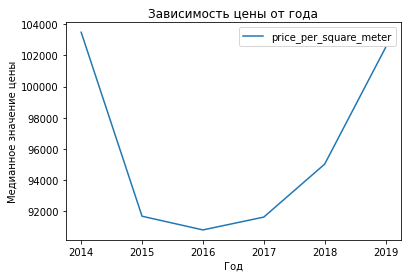

In [ ]:
pivot_year = data.pivot_table(index='year', values='price_per_square_meter', aggfunc = ['count','mean','median'])
pivot_year.plot(title= 'Зависимость цены от года', xlabel='Год', ylabel='Медианное значение цены', y='median')
pivot_year.columns= ['count','mean','median']
pivot_year.sort_values(by='median', ascending = False)

Вывод
1) В целом цена квадратного метра могла быть иначе от года к году. Мы рассматривает значения по факту, но я могу предположить, что спрос на квартиры
связан на прямую с подготовкой чемпионата мира в России, было много работы и соответственно она оплачивалась, так как на это был выделен огромный
бюджет.

In [ ]:
location_pivot = data.pivot_table(index = 'locality_name', values = 'price_per_square_meter', aggfunc=['count', 'mean'])
location_pivot.columns = ['count', 'mean']
#самая высокая стоимость
location_pivot[location_pivot['mean']==location_pivot['mean'].max()]
#самая низкая стоимость
location_pivot[location_pivot['mean']==location_pivot['mean'].min()]
location_pivot = location_pivot.sort_values('count', ascending = False).head(10)
location_pivot.head(10)


                 count           mean
locality_name                        
санкт-петербург  14921  108544.386167
мурино             588   86064.363946
кудрово            471   95325.726115
шушары             440   78676.904545
всеволожск         394   67165.309645
пушкин             359  101715.256267
колпино            337   75332.866469
парголово          326   90331.840491
гатчина            305   68810.921311
выборг             233   58250.240343

Вывод:
Исходя из полученных данный, видим, что самая высокая стоимость квадратного метра в Санкт-Перетбурге, а самая низкая в выборге!

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22844 entries, 0 to 23698
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   total_images            22844 non-null  int64         
 1   last_price              22844 non-null  float64       
 2   total_area              22844 non-null  float64       
 3   first_day_exposition    22844 non-null  datetime64[ns]
 4   rooms                   22844 non-null  int64         
 5   ceiling_height          22844 non-null  float64       
 6   floors_total            22760 non-null  float64       
 7   living_area             22844 non-null  float64       
 8   floor                   22844 non-null  int64         
 9   is_apartment            22844 non-null  bool          
 10  studio                  22844 non-null  bool          
 11  open_plan               22844 non-null  bool          
 12  kitchen_area            22844 non-null  float6

In [ ]:
data.query('locality_name == "санкт-петербург"')['center_distance'].describe()


count    14874.000000
mean        11.892766
std          4.740265
min          0.000000
25%          9.000000
50%         12.000000
75%         15.000000
max         29.000000
Name: center_distance, dtype: float64

Empty DataFrame
Columns: []
Index: []

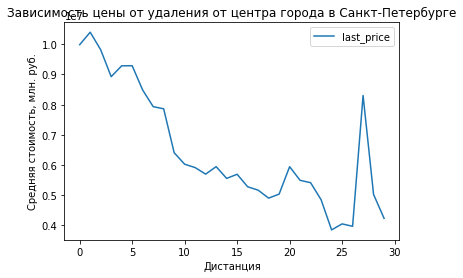

In [ ]:
#строим график по данным из Санкт-Петербурга
spb_center = data.query('locality_name == "санкт-петербург"').pivot_table(index='center_distance', values='last_price', aggfunc='mean')
spb_center.plot(title= 'Зависимость цены от удаления от центра города в Санкт-Петербурге', xlabel='Дистанция', ylabel='Средняя стоимость, млн. руб.')
#выводим таблицу стоимости в пределах 10 км
data.query('locality_name == "Санкт-Петербург" and center_distance < 7').pivot_table(values='last_price', index='center_distance')

Вывод:
По графику видно, что самые дорогие квартиры в центре и их стоимость падает с удалением от центра

# Общий вывод:
1) Мы обработали полученный архив данных из 23699 записей, заполнили пропущенные значения, избавились от ненужных данных, заменили тип колонки, там где это необходимо, вывели количество уникальных значений.
2) Посчитали и добавили в таблицу цену цена одного квадратного метра; 
день недели публикации объявлени) 
месяц публикации объявления;
год публикации объявлен я;
тип этажа квар; »);
расстояние до центра города в киломений).
3) Изучили следующие параметры на наличие выбивающихся значенобщая площадь, 
жилая площад, 
площадь кух, ;
цена объе, а;
количество ко, ат;
высота пот, ков;
тип этажа кв, ой»);
общее количество этажей,  доме;
расстояние до центра города , метрах;
расстояние до ближайшего паркаолков. Были определены аномалии в данных параметрах. Мы выявили при помощи диаграммы размаха, что нормальные значения продажи квартир варьируются от 1 до 600 дней. Мы выявили, что на стоимость квадратного метра квартиры большегород,  всего влияют количеств этаж квартиры, близость к центру. Незначительноратнет датань, месяц, год размещения и окм в центре СПБ.